In [14]:
import pandas as pd

# Hoja de Trabajo compilado para trabajar Napo en una sola.

In [ ]:
SUM = pd.read_excel(r"Sumaco\Sumaco_cellulose.xlsx") #REVISADO 
GAL = pd.read_excel(r"Galeras\Galeras_cellulose.xlsx")
SV = pd.read_excel(r"Selva Viva\iWUE_SV.xlsx")
OYC = pd.read_excel(r"Oyacachi-Guacamayos\iWUE_OYC_GUA.xlsx")
#SF = pd.read_excel(r"SF_control\iWUE_SF.xlxs")


In [16]:
###### GUACAMAYOS
OYC["species"] = OYC["species"].combine_first(OYC["species (det 2008!)"])

In [17]:
NAPO = pd.concat([SUM,GAL,SV,OYC])


In [18]:
### calcular nuevamente iWUE
import calculate_iWUE
%run calculate_iWUE

df = NAPO.apply(lambda row: calculate_iWUE(row, co2_dict), axis=1)
df.to_excel("NAPO.xlsx")
df.dtypes

Unnamed: 0                    int64
Sample-ID                    object
family                       object
genus                        object
species                      object
[C]%                        float64
δ13C (‰ v.s.V-PDB)          float64
Plot                         object
Year                        float64
old_treeID                   object
new_TreeID                   object
PlotID                       object
[N]                         float64
[C_b]%                      float64
δ15N (‰ v.s. V-PDB)         float64
bulk_δ13C (‰ v.s.V-PDB)     float64
JH herbarium collections     object
Type                         object
Site                         object
Elevation                   float64
△13C_cell                   float64
Ci                          float64
Ci/Ca                       float64
iWUE (μmol/mol)             float64
leaf_sample_ID_2011         float64
herbarium specimen          float64
altitud                     float64
species (det 2008!)         

c:\Users\selene.baez\.conda\envs\her_env\Lib\site-packages\seaborn\_base.py:1447: FutureWarning: reindexing with a non-unique Index is deprecated and will raise in a future version.
  self.plot_data[axis] = cat_data


ValueError: cannot reindex on an axis with duplicate labels

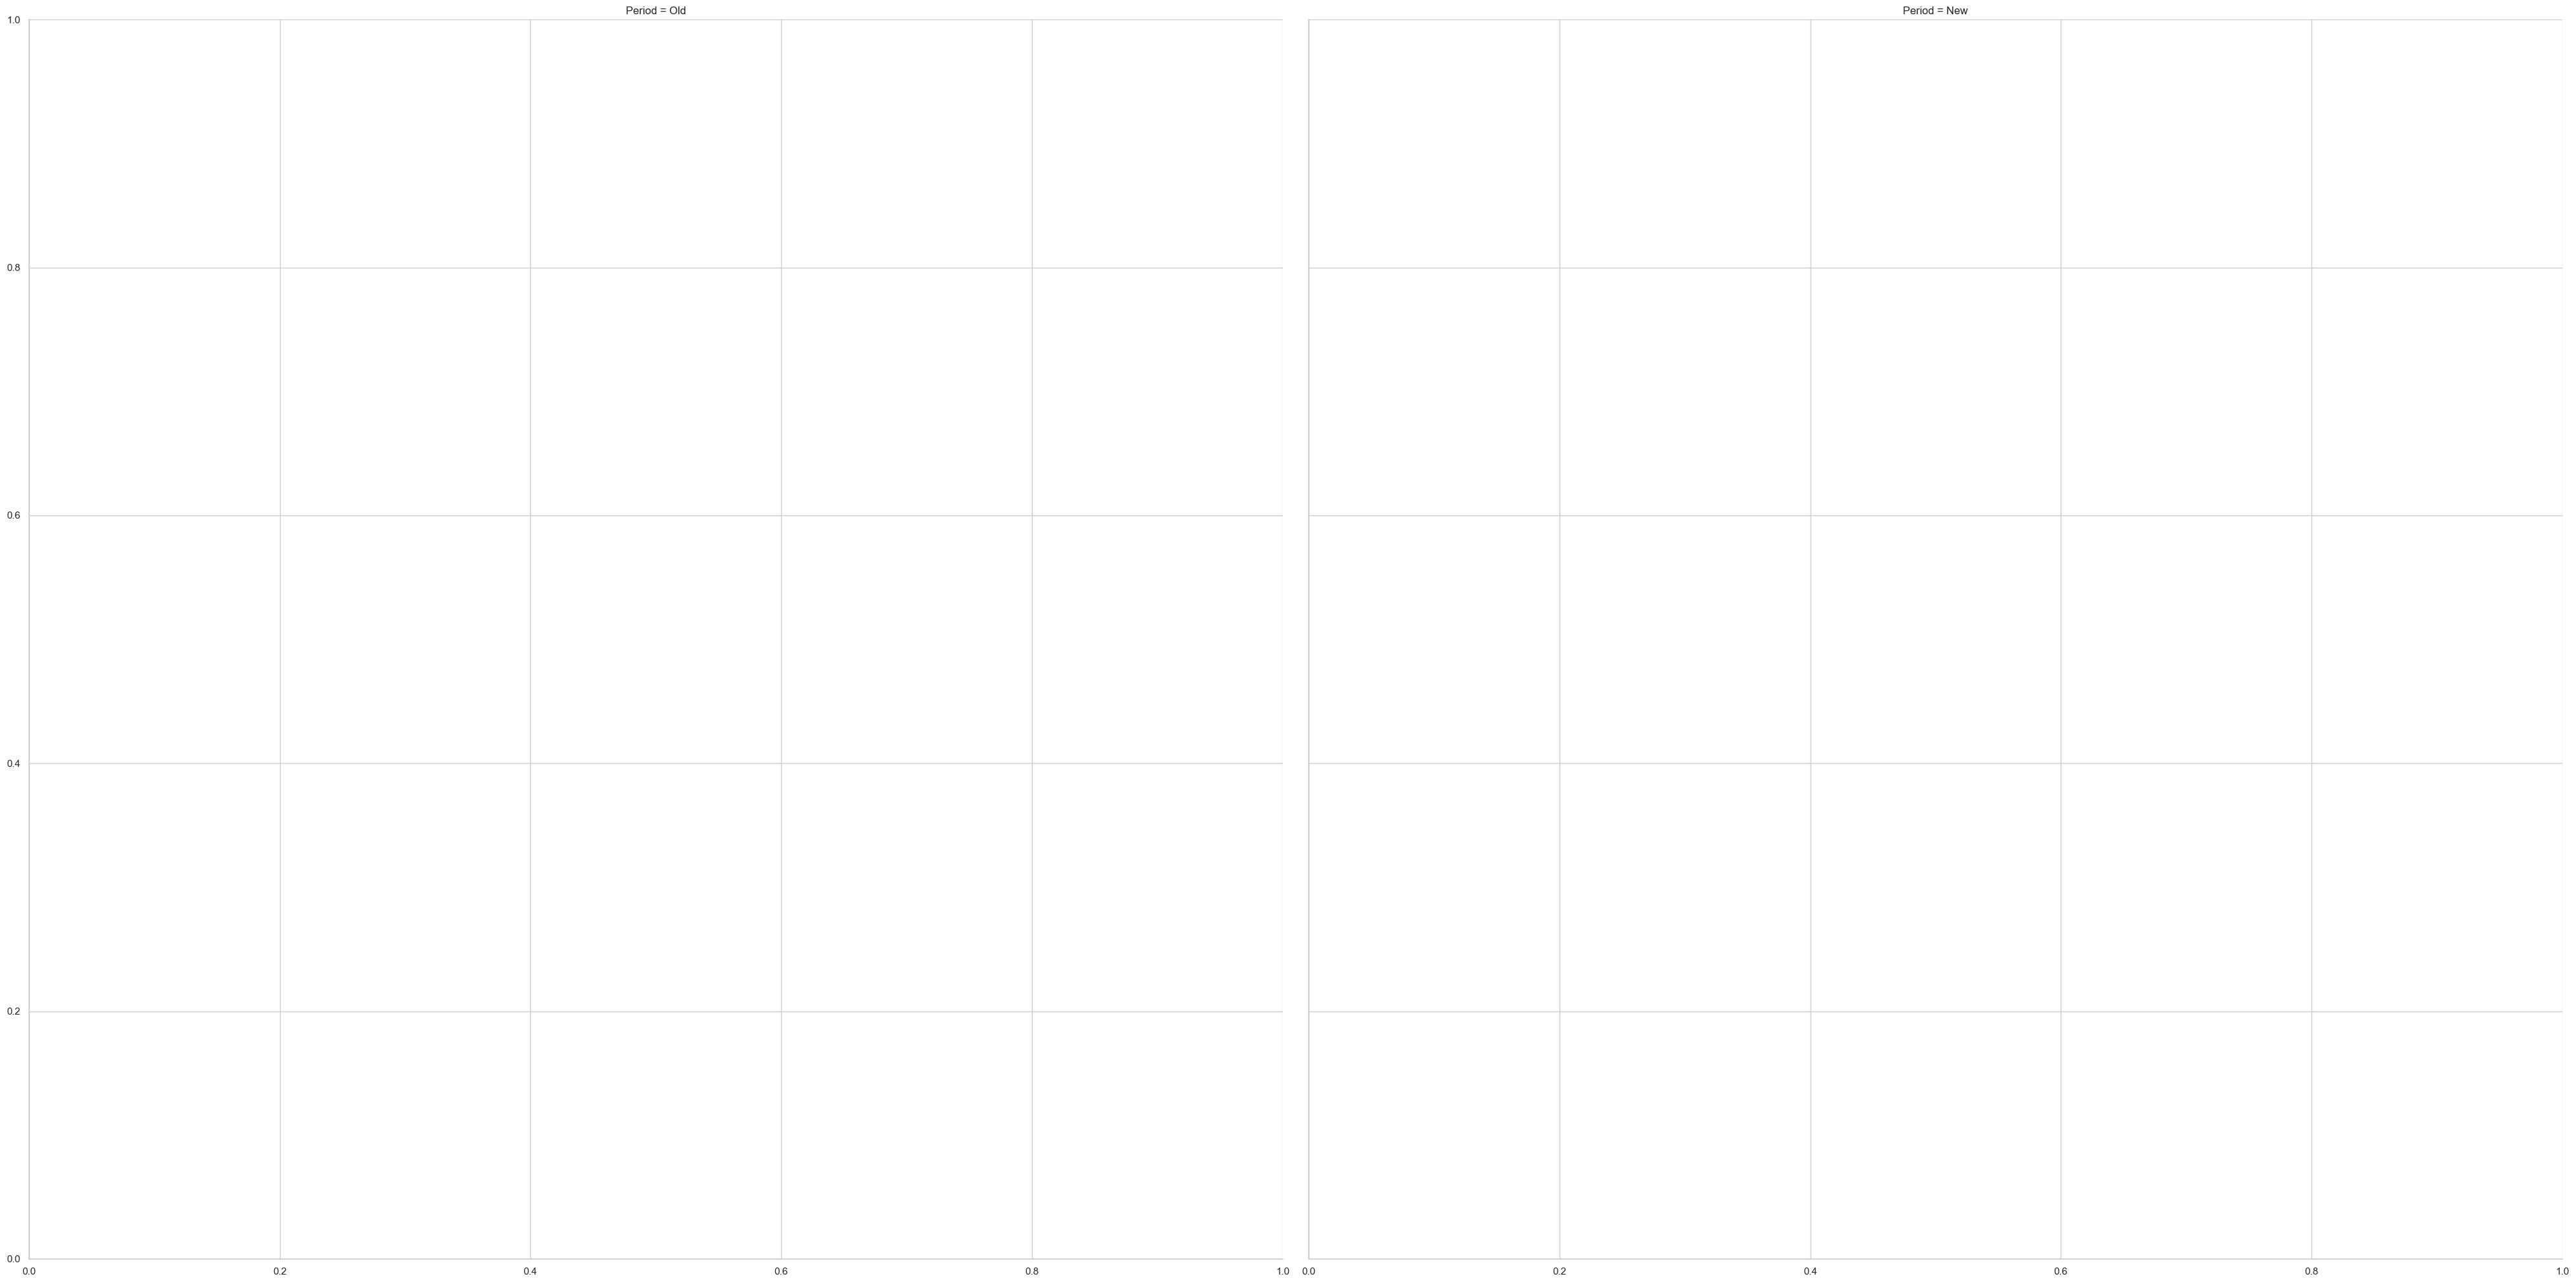

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

df["Period"] = df["Year"].map({
    2005: "Old",
    2006: "Old",
    2007: "Old",
    2009: "Old",
    2011: "Old",
    2023: "New",
    2024: "New",
    2025: "New"
})
sns.set(style="whitegrid")

g = sns.catplot(
    data=df,
    x="iWUE (μmol/mol)",
    y="family",
    col="Period",
    kind="bar",
    height=20,
    aspect=1,
    sharex=True,
    sharey=True
)

g.set_axis_labels("Mean iWUE", "Family")
g.set_titles("Year: {col_name}")

plt.tight_layout()
plt.show()

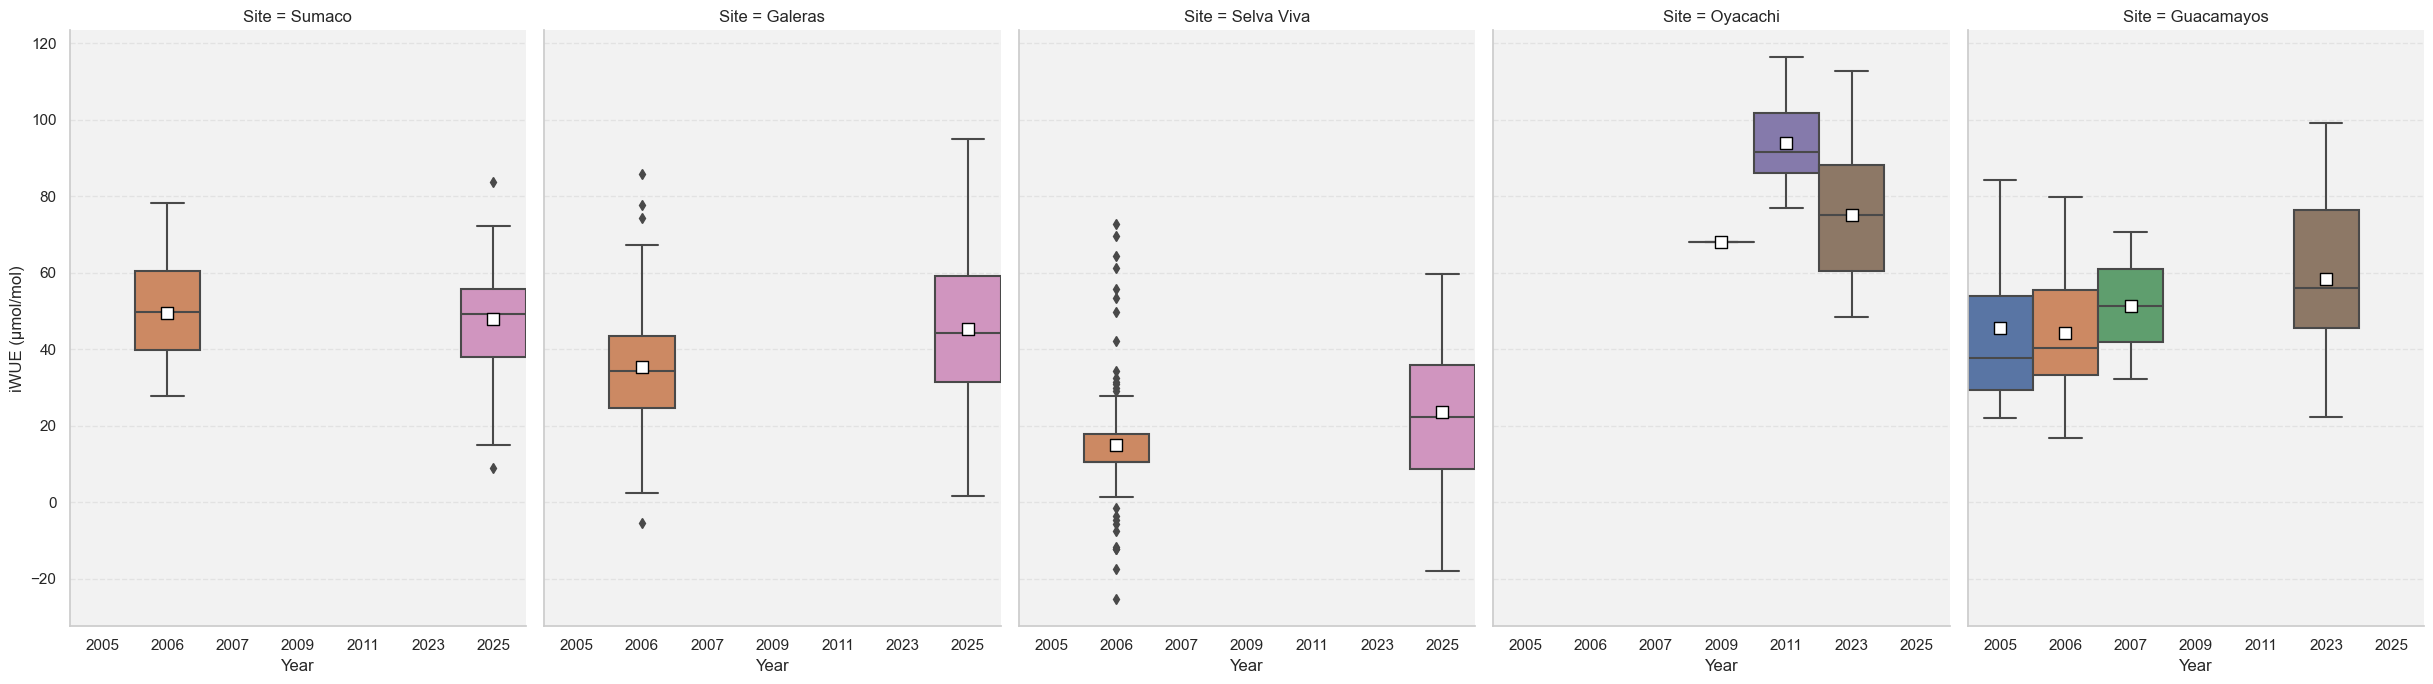

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt


g = sns.catplot(
    data=df,
    x="Year",
    y="iWUE (μmol/mol)",
    col="Site",
    kind="box",
    height=7,          # menos alto pero más balanceado
    aspect=0.7,
    width=1       # opcional: quitar outliers (ruido visual)
)
for ax in g.axes.flat:
    ax.set_facecolor("#f2f2f2")   # gris más suave
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    
for ax in g.axes.flat:
    site = ax.get_title().split(" = ")[-1]

    subset = df[df["Site"] == site]

    years = sorted(df["Year"].unique())

    means = subset.groupby("Year")["iWUE (μmol/mol)"].mean().reindex(years)

    ax.scatter(
    range(len(years)),
    means,
    color="white",
    edgecolor="black",
    marker="s",
    s=80,
    zorder=5
    )

plt.tight_layout()
plt.show()

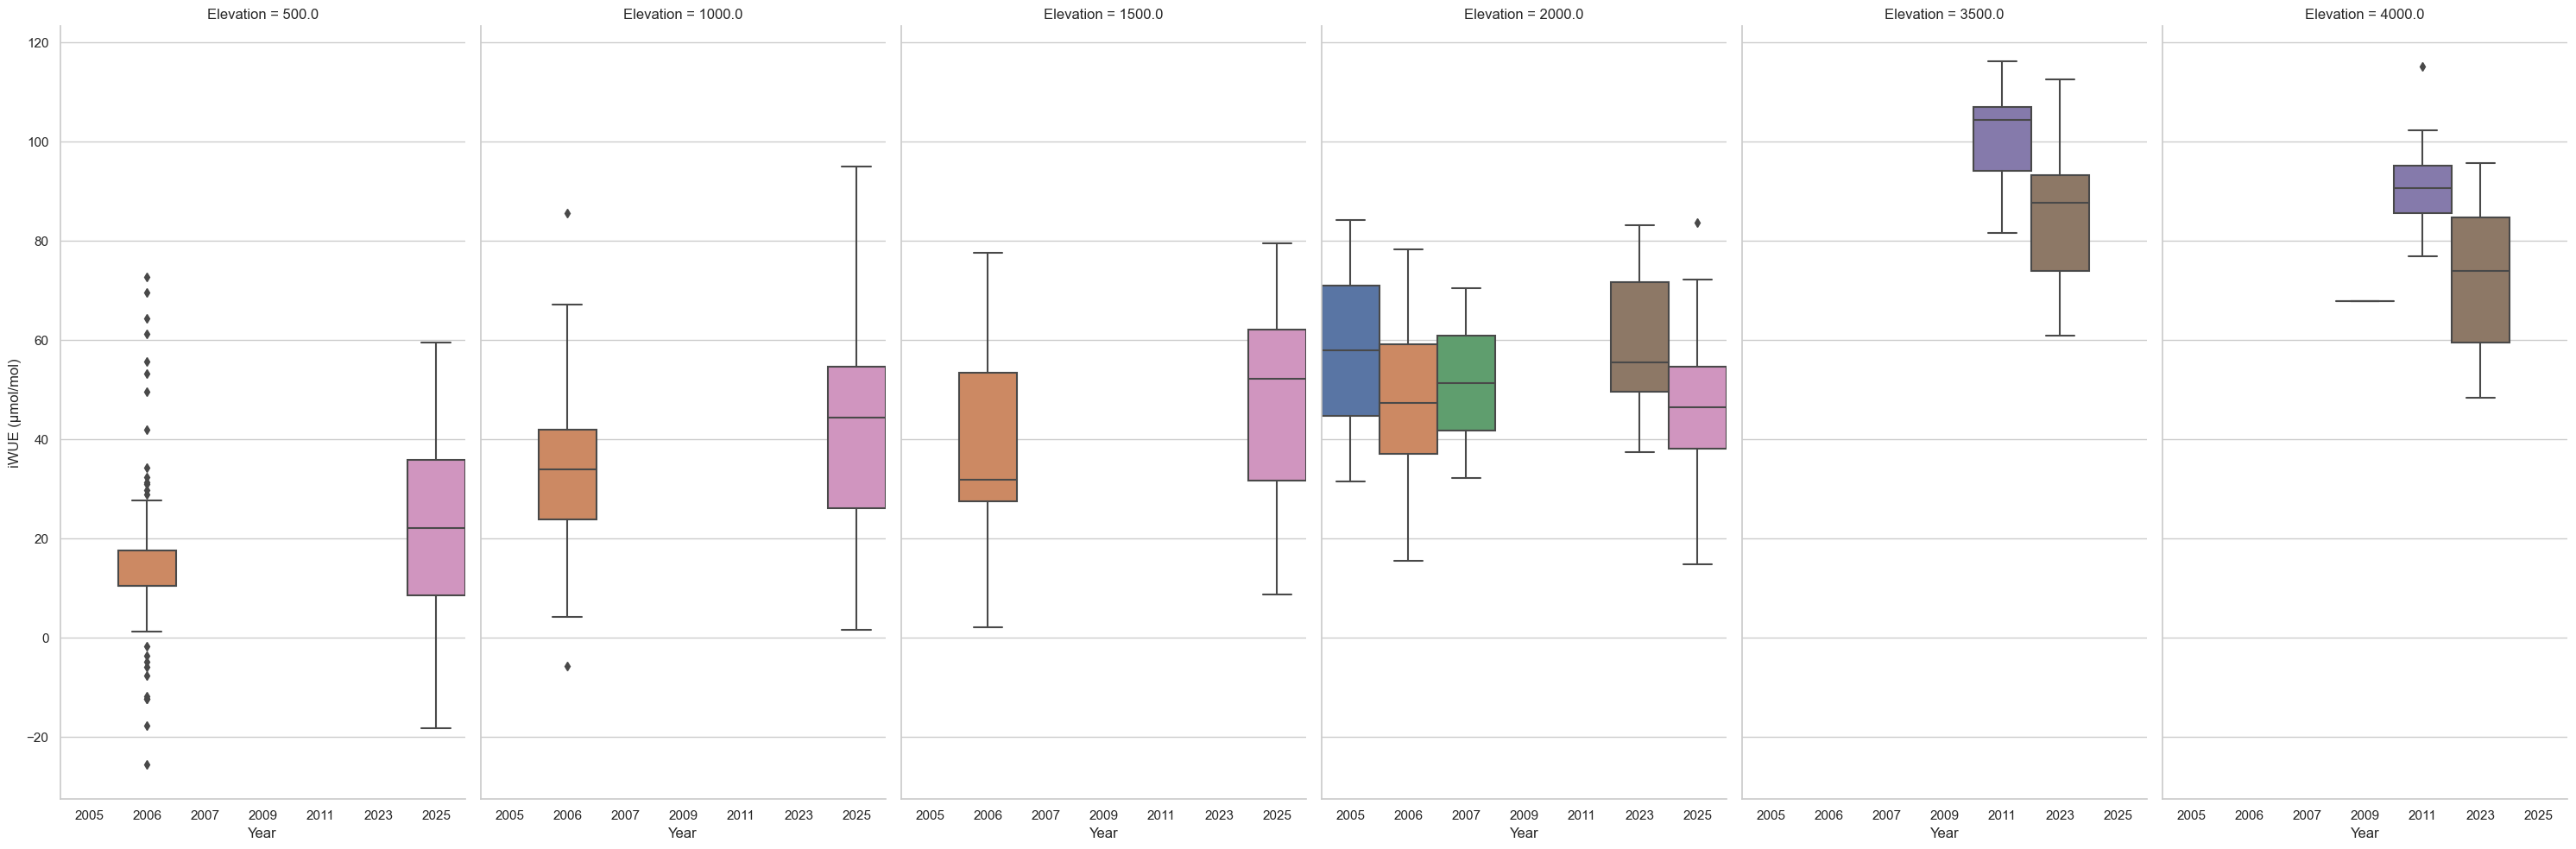

In [ ]:

g = sns.catplot(
    data=df,
    x="Year",
    y="iWUE (μmol/mol)",
    col="Elevation",
    kind="box",
    height=10,          # menos alto pero más balanceado
    aspect=0.5,
    width=1      
)

plt.tight_layout()
plt.show()